In [1]:
#Importing needed libraries
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import dataquality as dq
import plotly.express as px

In [2]:
#Making the connection to the data on SQLite
con = sqlite3.connect(r'C:\Users\trfk1\OneDrive\Desktop\Class\Final Project\retail_data')
marketing = pd.read_sql_query('''select c.*, 
ca.AcceptedCmp3,	
ca.AcceptedCmp4,	
ca.AcceptedCmp5,	
ca.AcceptedCmp1,	
ca.AcceptedCmp2,	
ca.Response, 
t.Recency,		
t.MntWines,		
t.MntFruits,		
t.MntMeatProducts,		
t.MntFishProducts,		
t.MntSweetProducts,		
t.MntGoldProds,		
t.NumDealsPurchases,		
t.NumWebPurchases,		
t.NumCatalogPurchases,		
t.NumStorePurchases,		
t.NumWebVisitsMonth
FROM Customers c
LEFT JOIN Campaign ca ON c.CustomerID = ca.CustomerID
LEFT JOIN Transactions t ON c.CustomerID = t.CustomerID;
 ''', con)
con.close()
marketing.head()

,CustomerID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Ct_Customer2,Complain,Age,...,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0,1985,Graduation,Married,70951.0,0,0,4/5/2013,0,41,...,10.0,554.0,254.0,87.0,54.0,1,3,4,9,1
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,65,...,5.0,64.0,7.0,0.0,37.0,1,7,3,7,5
2,9,1975,Master,Single,46098.0,1,1,8/18/2012,0,51,...,0.0,27.0,0.0,0.0,36.0,4,3,2,2,8
3,13,1947,PhD,Widow,25358.0,0,1,7/22/2013,0,79,...,0.0,5.0,0.0,0.0,8.0,2,1,0,3,6
4,17,1971,PhD,Married,60491.0,0,1,6/9/2013,0,55,...,47.0,237.0,12.0,19.0,76.0,4,6,11,7,5


In [3]:
#Making a copy of the imported data
data = marketing.copy()
data.sample()

,CustomerID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Ct_Customer2,Complain,Age,...,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
1995,10129,1966,Graduation,Together,82427.0,0,0,12/3/2014,0,60,...,147.0,509.0,104.0,107.0,107.0,1,3,5,12,1


### Top 5 Rows



,CustomerID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Ct_Customer2,Complain,Age,...,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0,1985,Graduation,Married,70951.0,0,0,4/5/2013,0,41,...,10.0,554.0,254.0,87.0,54.0,1,3,4,9,1
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,65,...,5.0,64.0,7.0,0.0,37.0,1,7,3,7,5
2,9,1975,Master,Single,46098.0,1,1,8/18/2012,0,51,...,0.0,27.0,0.0,0.0,36.0,4,3,2,2,8
3,13,1947,PhD,Widow,25358.0,0,1,7/22/2013,0,79,...,0.0,5.0,0.0,0.0,8.0,2,1,0,3,6
4,17,1971,PhD,Married,60491.0,0,1,6/9/2013,0,55,...,47.0,237.0,12.0,19.0,76.0,4,6,11,7,5


### Bottom 5 Rows



,CustomerID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Ct_Customer2,Complain,Age,...,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
2235,11178,1972,Master,Single,42394.0,1,0,3/23/2014,0,54,...,2.0,10.0,0.0,1.0,4.0,1,1,0,3,7
2236,11181,1949,PhD,Married,156924.0,0,0,8/29/2013,0,77,...,1.0,2.0,1.0,1.0,1.0,0,0,0,0,0
2237,11187,1978,Basic,Single,26487.0,1,0,5/20/2013,0,48,...,8.0,10.0,12.0,14.0,23.0,3,2,1,3,5
2238,11188,1957,Graduation,Together,26091.0,1,1,2/25/2014,0,69,...,10.0,19.0,8.0,17.0,20.0,3,2,1,3,5
2239,11191,1986,Graduation,Divorced,41411.0,0,0,7/12/2013,0,40,...,32.0,38.0,11.0,3.0,18.0,1,2,1,4,6


### Random Sample



...

np.int64(0)

### Statistics Summary



,CustomerID,Year_Birth,Income,Kidhome,Teenhome,Complain,Age,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,...,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,0.009375,57.194196,0.072768,0.074554,0.072768,...,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518
std,3246.662198,11.984069,25037.797168,0.538398,0.544538,0.096391,11.984069,0.259813,0.262728,0.259813,...,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,0.000000,49.000000,0.000000,0.000000,0.000000,...,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,5458.500000,1970.000000,51741.500000,0.000000,0.000000,0.000000,56.000000,0.000000,0.000000,0.000000,...,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,0.000000,67.000000,0.000000,0.000000,0.000000,...,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,1.000000,133.000000,1.000000,1.000000,1.000000,...,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000


### First 10 Values Chart



,index,0
0,CustomerID,2240
1,Year_Birth,59
2,Education,5
3,Marital_Status,8
4,Income,1975
5,Kidhome,3
6,Teenhome,3
7,Ct_Customer2,663
8,Complain,2
9,Age,59


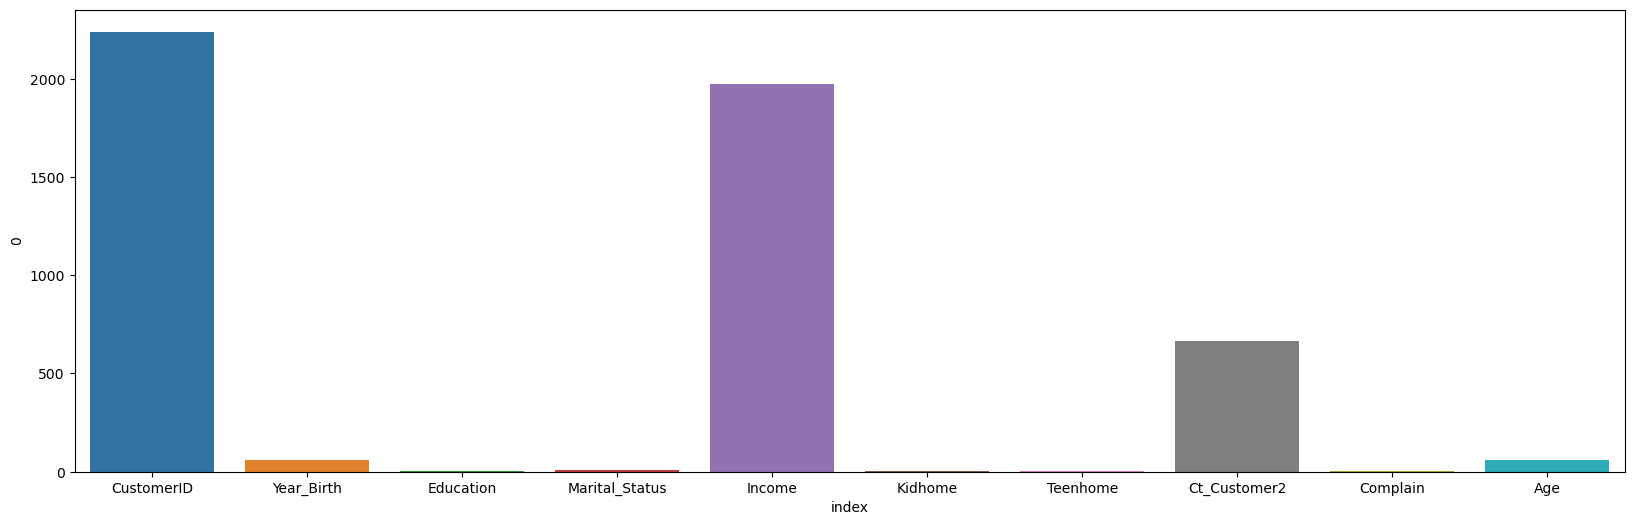

In [4]:
#A Formula created for basic Data cleaning
dq.data_check(marketing)

In [5]:
#Changing the data type for Ct_Customer from an object to a datetime format
data['Ct_Customer2'] = pd.to_datetime(data['Ct_Customer2'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Ct_Customer2         2240 non-null   datetime64[ns]
 8   Complain             2240 non-null   int64         
 9   Age                  2240 non-null   int64         
 10  Age_Group            2240 non-null   object        
 11  AcceptedCmp3         2240 non-null   int64         
 12  AcceptedCmp4         2240 non-null   int64         
 13  AcceptedCmp5         2240 non-nul

In [6]:
#Updating the Column Name to match the rest of the Dataset
data.rename(columns = {'MntGoldProds': 'MntGoldProducts'}, inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Ct_Customer2         2240 non-null   datetime64[ns]
 8   Complain             2240 non-null   int64         
 9   Age                  2240 non-null   int64         
 10  Age_Group            2240 non-null   object        
 11  AcceptedCmp3         2240 non-null   int64         
 12  AcceptedCmp4         2240 non-null   int64         
 13  AcceptedCmp5         2240 non-nul

In [7]:
#Replacing the 0's and 1's to 'No' and 'Yes' for a cleaner look while Charting
replace_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']
data[replace_cols] = data[replace_cols].replace({0: 'No', 1: 'Yes'})
data.sample()

,CustomerID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Ct_Customer2,Complain,Age,...,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
1920,9733,1978,Basic,Together,24882.0,1,0,2012-09-09,0,48,...,4.0,10.0,29.0,0.0,36.0,1,1,1,2,6


In [8]:
#Expanding out all of the columns in the data for better visibility
pd.set_option('display.max_columns', None)
data.sample()

,CustomerID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Ct_Customer2,Complain,Age,Age_Group,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProducts,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
2021,10240,1949,Graduation,Together,69372.0,0,0,2013-02-19,0,77,56+,No,Yes,Yes,No,No,Yes,10,997.0,26.0,269.0,34.0,13.0,42.0,1,10,4,6,4


In [9]:
#Defining numerical and categorical columns to make easier working with chart creation
numerical_data = [
    'Age', 'Year_Birth', 'Income', 'Recency', 'Kidhome', 'Teenhome', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

categorical_data = ['Education', 'Marital_Status', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']

In [10]:
#Creating the statistical data for the numerical columns
data[numerical_data].describe()

KeyError: "['MntGoldProds'] not in index"

In [ ]:
#Laying out the structure of the charts
nrows, ncolumns = (5,4)
fig, axes = plt.subplots(nrows, ncolumns, figsize=(18,22))
axes = axes.flatten()

for a, col in enumerate(numerical_data):
    sns.boxplot(data = data, y = col, ax = axes[a], width = 0.4)
    axes[a].set_title(col)
    axes[a].set_xlabel('')
    
#To hide the final 3 empty charts at the end
for b in range(len(numerical_data), len(axes)):
    axes[b].set_visible(False)
    
plt.suptitle('Distribution of Numerical Values')
plt.tight_layout()
plt.show()

In [ ]:
#Creating a Histogram to look at with the boxplot
data[numerical_data].hist( bins = 20, figsize = (20, 15), edgecolor = 'white')
plt.suptitle('Distribution of Numerical Variables')
plt.tight_layout()
plt.show()

In [ ]:
#Laying out the structure of the charts
nrows, ncolumns = (5,4)
fig, axes = plt.subplots(nrows, ncolumns, figsize=(18,22))
axes = axes.flatten()

#Using enumerate to be able to create an index for the loop
for a, col in enumerate(numerical_data):
    sns.kdeplot(data = data, y = col, ax = axes[a], fill = True)
    
#To hide the final 3 empty charts at the end
for b in range(len(numerical_data), len(axes)):
    axes[b].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Creating Bar Charts for the Categorical Variables
for col in categorical_data:
    count_data = data[col].value_counts().sort_index()

    plt.figure(figsize = (8, 4))
    sns.barplot(x = count_data.index, y = count_data.values)
    plt.title(f'Bar Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [ ]:
#Due to the structure of the data in the Age_Group column, I had to separate it from the Categorical_data and use a different chart 
order = ['26-35', '36-45', '46-55', '56+']
sns.countplot(data = data, x = 'Age_Group', order = order)
plt.title('Age Group VS Count')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

##### Creating Scatterplots to be able to identify outliers within the Numerical Variables
pairplot was too big
try scatter plot again

In [ ]:
#Creating a scatterplot to view outliers in the MntMeatProducts and the MntFishProducts against Age Groupings
sns.scatterplot(data, x = 'MntMeatProducts', y = 'MntFishProducts', hue = 'Age')
plt.show()

In [ ]:
#Changing Response back to '0' and '1' to be able to make calculations
update_col = ['Response']
data[update_col] = data[update_col].replace({'No': 0, 'Yes': 1})
data.sample()

In [ ]:
#Performing different correlation tests to see the relationships between the Numerical Data and the Responses
corr_matrix = data[['Income', 'Response']].corr()
print('\nIncome VS Respones:')
print(corr_matrix)

kh_v_response = data[['Kidhome', 'Response']].corr()
print('\nKid Home VS Responses:')
print(kh_v_response)

deals_v_response = data[['NumDealsPurchases', 'Response']].corr()
print('\nNumber of Deals with Purchases VS Responses:')
print(deals_v_response)

storep_v_response = data[['NumStorePurchases', 'Response']].corr()
print('\nNumber of Store Purchases VS Responses:')
print(storep_v_response)

In [ ]:
#Using a Scatterplot to see the relationship between Income and Response 
sns.scatterplot( data, x = 'Income', y = 'Response', hue = 'Response')
plt.title('Income VS Responses')
plt.show()

In [ ]:
#Performed multiple Chi-Square Tests through a for loop to explore the relationship between the Categorical data and the Response

categorical_data = ['Education', 'Marital_Status', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']

for col in categorical_data:
    contingency_table = data.pivot_table(index = col, columns = 'Response', aggfunc = 'size', fill_value = 0)
    print(f'Contingency Table: {col}')
    print(contingency_table)
    
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    print(f'Chi2     : {chi2:.4f}')
    print(f'P-Value  : {p_value:.4f}')
    print(f'Degrees of Freedom: {dof}')
    print(f'Significant: {"Yes" if p_value < 0.05 else "No"}')
    print()

In [ ]:
#Compairing the relationships between the Categorical data and the Numerical data
fig = px.violin(data, y= 'NumWebPurchases', x = 'Age_Group', color = 'Marital_Status', points = 'outliers', category_orders = {'Age_Group': ['26-35', '36-45', '46-55', '56+']})
fig.write_image('webpurchases_v_age_group.png')
fig.show()

In [ ]:
#Saving file to be able to upload it into Tableau for Dashboard building
#data.to_json('Marketing_Campaign_Data.json', index = False)